<a href="https://colab.research.google.com/github/sabithamanoj/breast-cancer-ml-pipeline/blob/main/notebook/breast_cancer_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Project Introduction**

# Breast Cancer Prediction using Machine Learning

## Objective

Build a classical machine learning pipeline to classify breast tumors as malignant or benign.

Workflow:

Data Loading →
Exploratory Data Analysis →
Data Preprocessing →
Model Training →
Evaluation →
Explainability


#**2. Import Libraries**

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

import warnings
warnings.filterwarnings("ignore")

## **3. Dataset Description**

This project uses the Breast Cancer Wisconsin Diagnostic Dataset available from Scikit-learn.

The dataset contains measurements computed from digitized images of breast mass samples. The objective is to classify tumors as:

- **Malignant**: Cancerous tumor
- **Benign**: Non-cancerous tumor

### Dataset Characteristics

- Number of samples: 569
- Number of features: 30 numerical features
- Target classes: 2
- Machine Learning Task: Binary Classification

The features describe characteristics of cell nuclei such as:

- Radius
- Texture
- Perimeter
- Area
- Smoothness
- Compactness
- Concavity
- Symmetry
- Fractal dimension

The goal is to build a machine learning pipeline that can accurately classify tumors using these features.


**Load** **Dataset**

In [3]:
from sklearn.datasets import load_breast_cancer

# Load dataset
cancer = load_breast_cancer()

# Create feature dataframe
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Create target dataframe
y = pd.Series(
    cancer.target,
    name="target"
)

# Display first rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**#Dataset Shape**

### Dataset Dimensions

Let's check the number of samples and features available in the dataset.

In [4]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (569, 30)
Target shape: (569,)


 **Convert Target Labels**

The original dataset uses numeric labels:

- 0 → Malignant
- 1 → Benign

For better understanding, we create readable class names.

In [5]:
target_names = {
    0: "Malignant",
    1: "Benign"
}

y_labels = y.map(target_names)

y_labels.head()

,target
0,Malignant
1,Malignant
2,Malignant
3,Malignant
4,Malignant


#**4. Exploratory Data Analysis (EDA)**

**4.1 Basic Information**

Exploratory Data Analysis helps understand:

- Dataset structure
- Feature distributions
- Class balance
- Relationships between variables

Before training models, we analyze the dataset characteristics.

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

**4.2 Statistical Summary**

In [7]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**4.3 Check Missing Values**

### Missing Value Analysis

Machine learning models require clean numerical inputs.
We check whether the dataset contains missing values.

In [8]:
missing_values = X.isnull().sum()

missing_values[missing_values > 0]

,0


**4.4 Class Distribution Visualization**

### Target Class Distribution

A balanced dataset helps machine learning models learn both classes effectively.

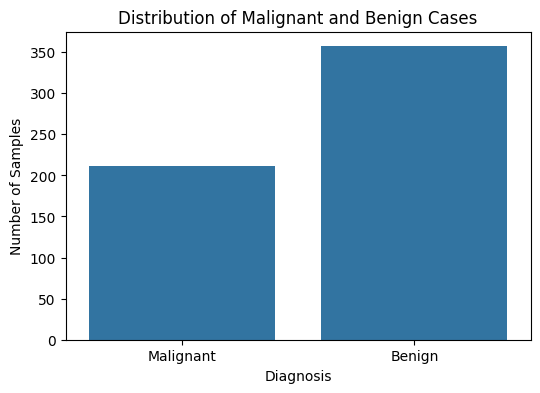

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_labels
)

plt.title("Distribution of Malignant and Benign Cases")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

**4.5 Feature Distribution**

### Feature Distribution

Different features have different scales and distributions.
Visualization helps identify patterns and possible outliers.

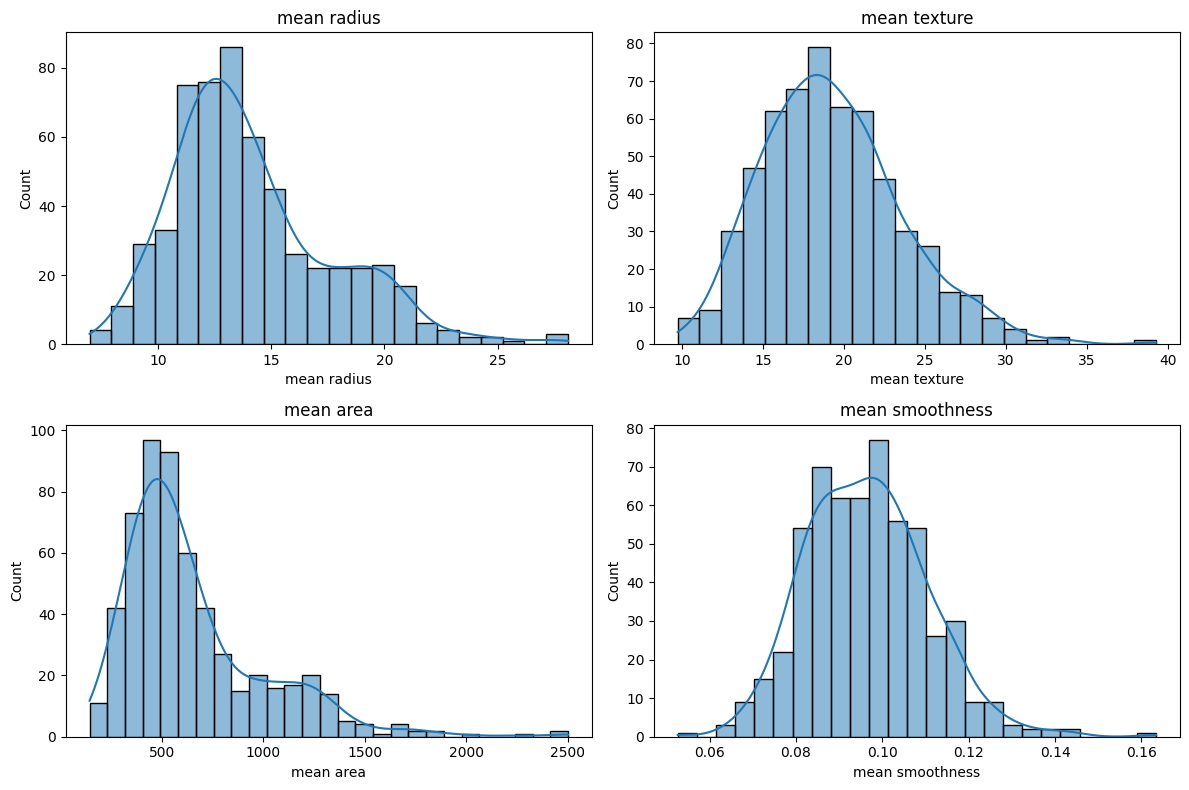

In [10]:
features_to_plot = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness"
]

plt.figure(figsize=(12,8))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2,2,i+1)
    sns.histplot(
        X[feature],
        kde=True
    )
    plt.title(feature)

plt.tight_layout()
plt.show()

**4.6 Correlation Analysis**

### Feature Correlation Analysis

Highly correlated features may contain similar information.

A correlation heatmap helps identify relationships between variables.

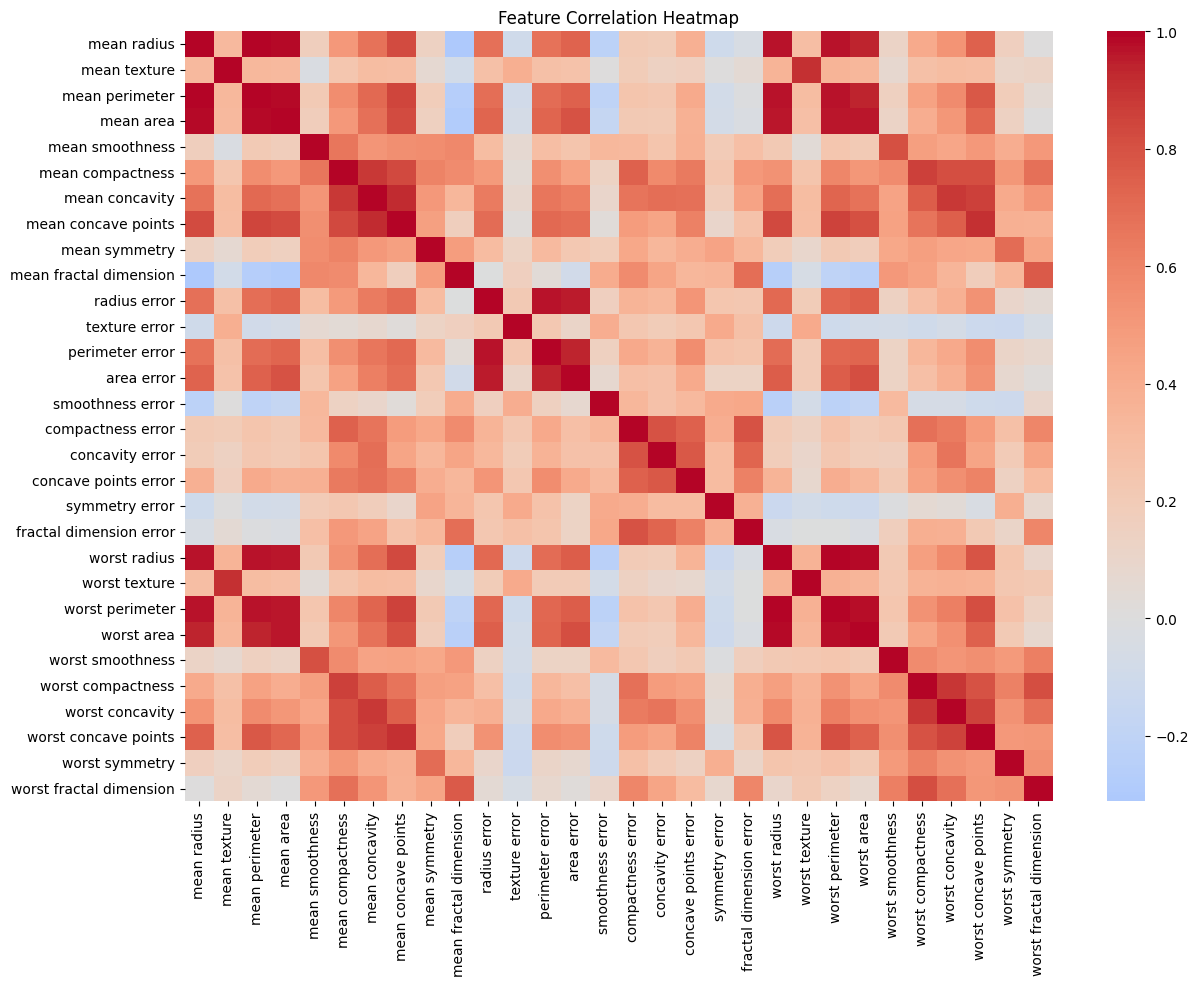

In [11]:
plt.figure(figsize=(14,10))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

#**5. Data Preprocessing**

**Train-Test Split**

Machine learning models should be evaluated on unseen data.

The dataset is divided into:

- Training data: Used for learning patterns
- Testing data: Used for final evaluation

Stratified splitting maintains the same class distribution in both sets.

In [12]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


#**Feature Scaling**

Different features have different ranges.

For example:

- Radius values are around 10-30
- Area values can exceed 2000

Standardization transforms features to:

Mean = 0

Standard deviation = 1

In [26]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#**6. Machine Learning Model Training**

We compare multiple classical machine learning algorithms:

1. Logistic Regression
2. Support Vector Machine
3. Random Forest
4. Gradient Boosting

The goal is to identify the best-performing model.

**Logistic Regression**

In [27]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

**Support Vector Machine**

In [15]:
from sklearn.svm import SVC


svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

**Random Forest**

In [16]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

**Gradient Boosting**

In [17]:
from sklearn.ensemble import GradientBoostingClassifier


gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(random_state=42)

#**7. Model Evaluation**

Models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC Score

In medical applications, recall is especially important because false negatives can have serious consequences.


**Evaluation Function**

**7.1 Accuracy, Precision, Recall, F1-score**

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test,predictions),
        "Precision": precision_score(y_test,predictions),
        "Recall": recall_score(y_test,predictions),
        "F1 Score": f1_score(y_test,predictions)
    }

**Compare Models**

In [20]:
results = pd.DataFrame({

"Logistic Regression":
evaluate_model(
    lr_model,
    X_test_scaled,
    y_test
),

"SVM":
evaluate_model(
    svm_model,
    X_test_scaled,
    y_test
),

"Random Forest":
evaluate_model(
    rf_model,
    X_test,
    y_test
),

"Gradient Boosting":
evaluate_model(
    gb_model,
    X_test,
    y_test
)

}).T


results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.982456,0.986111,0.986111,0.986111
SVM,0.982456,0.986111,0.986111,0.986111
Random Forest,0.956140,0.958904,0.972222,0.965517
Gradient Boosting,0.956140,0.946667,0.986111,0.965986


**7.2 Confusion Matrix**

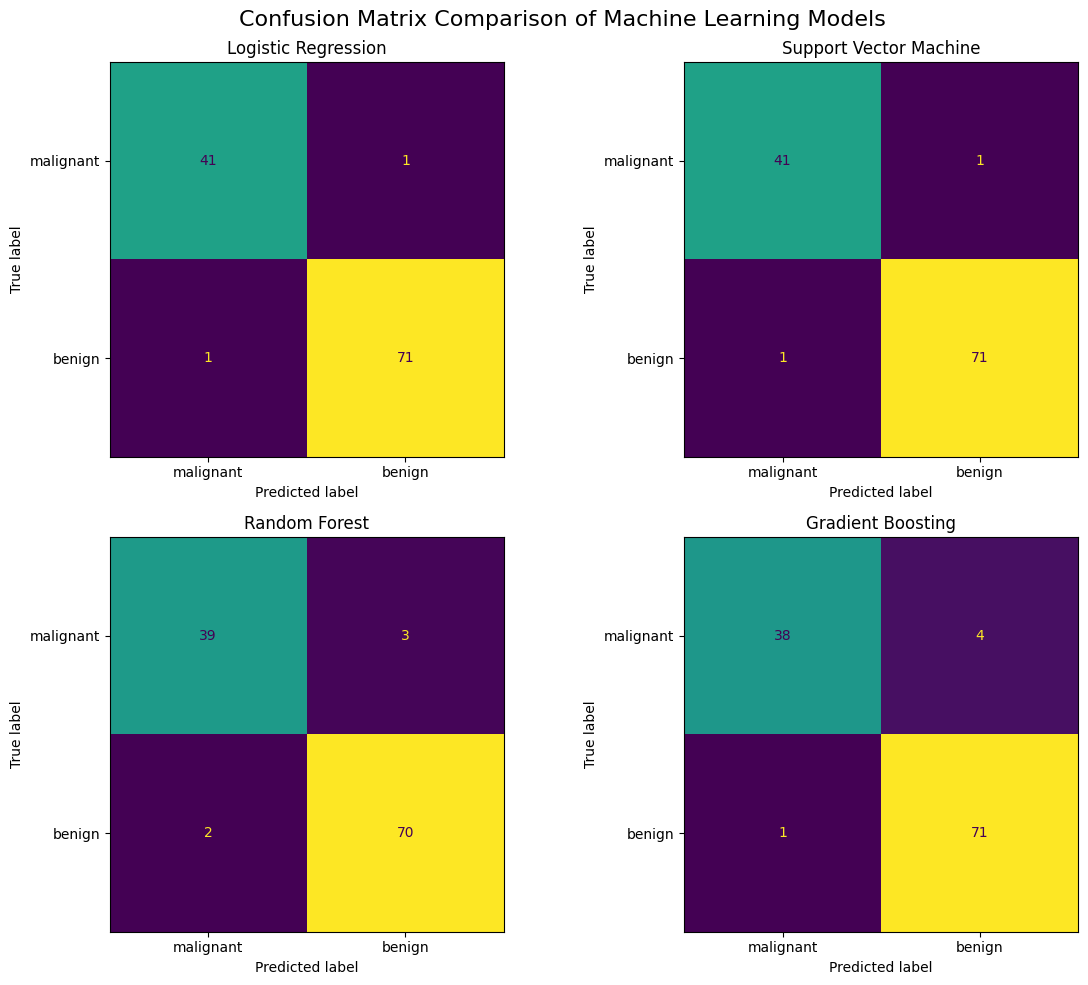

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Dictionary of trained models
models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Support Vector Machine": (svm_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test)
}

# Create a 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.ravel()

# Plot confusion matrix for each model
for ax, (model_name, (model, X_eval)) in zip(axes, models.items()):

    # Predict labels
    y_pred = model.predict(X_eval)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=cancer.target_names
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(model_name)

plt.suptitle(
    "Confusion Matrix Comparison of Machine Learning Models",
    fontsize=16
)

plt.tight_layout()

plt.show()


 Save the figure

In [22]:
plt.savefig(
    "confusion_matrix_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>


**7.3 ROC Curve and AUC**

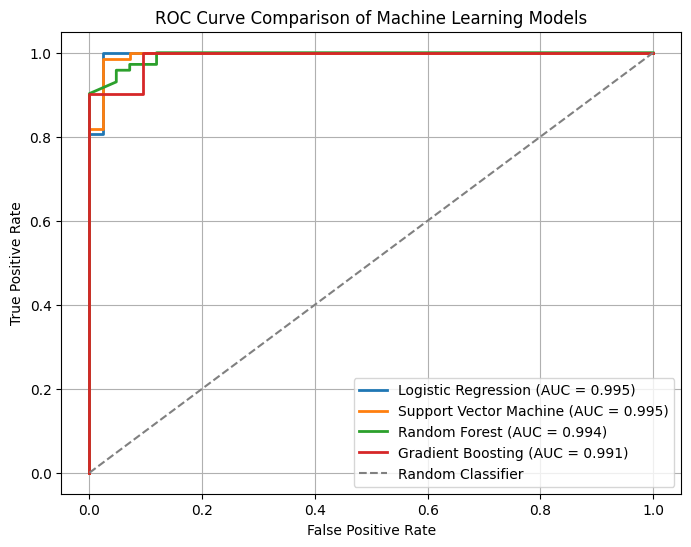

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

# Dictionary of trained models
models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Support Vector Machine": (svm_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test)
}

plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for model_name, (model, X_eval) in models.items():

    # Predicted probabilities for the positive class
    y_prob = model.predict_proba(X_eval)[:, 1]

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()



Save the plot

In [24]:
plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#**8. Model Explainability**

Understanding which features influence predictions is important, especially in healthcare applications.

Random Forest provides feature importance values.



In [28]:
importance = pd.DataFrame({

"Feature": X.columns,

"Importance": rf_model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


**Visualization**

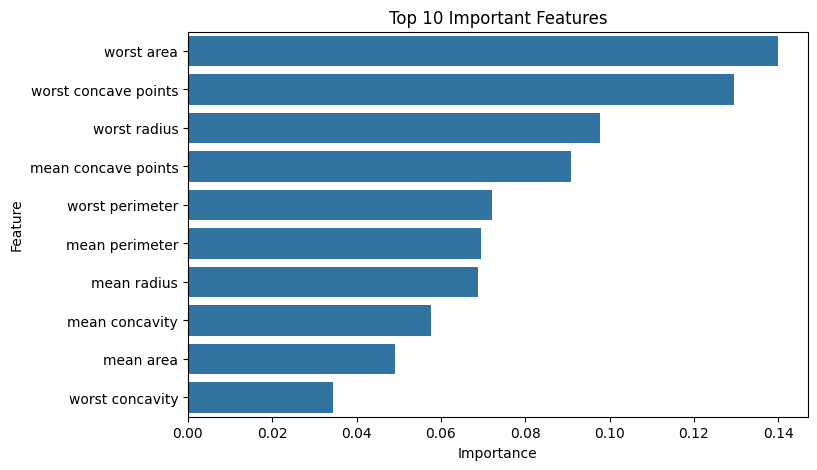

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

#**9. Save Best Model**

The trained model and scaler can be saved for future predictions and deployment.

In [30]:
import joblib


joblib.dump(
    rf_model,
    "breast_cancer_model.pkl"
)


joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

#**10. Conclusion**

This project demonstrated a complete classical machine learning workflow:

✓ Dataset loading  
✓ Exploratory data analysis  
✓ Data preprocessing  
✓ Feature scaling  
✓ Multiple machine learning models  
✓ Performance comparison  
✓ Model explainability  

Among the evaluated models, the best-performing approach can be selected based on clinical requirements such as accuracy and recall.

### Future Improvements

Possible extensions:

- Hyperparameter optimization using GridSearchCV
- Cross-validation
- SHAP-based explainability
- MLflow experiment tracking
- Flask API deployment
- Docker containerization